### Student Name: Sagar Bhetwal  
### Course: Advanced Big Data and Data Mining  
### Instructor: Dr. Satish Penmatsa
### Lab Assignment: Clustering Techniques Using DBSCAN and Hierarchical Clustering

#### Overview  

This lab explores two clustering techniques: Agglomerative Hierarchical Clustering and DBSCAN Clustering, using the Wine dataset from the `sklearn` library. The objective is to understand how clustering algorithms group data points, how parameter choices affect results, and how clustering quality can be evaluated using performance metrics and visual analysis.


#### Step 1: Data Preparation and Exploration

In this step, the Wine dataset is loaded from `sklearn.datasets` and converted into a pandas DataFrame for easier analysis. Basic exploratory analysis is then performed using `.head()`, `.info()`, and `.describe()`. Since clustering algorithms are distance-based, feature standardization is applied so that all variables contribute equally to the clustering process.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the Wine dataset
wine = load_wine()

# Create a DataFrame from the dataset
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add the target labels for evaluation purposes only
df['target'] = wine.target

# Display first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [4]:
# Display summary statistics
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


#### Initial Observations

The Wine dataset contains multiple continuous chemical properties of wine samples. The dataset also includes a target class representing the actual wine category. Although clustering is an unsupervised learning task and does not use the target labels during training, the target labels can still be used later to evaluate clustering quality using external metrics such as homogeneity and completeness.

In [5]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

In [6]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows of standardized data
X_scaled_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


#### Why Standardization is Necessary

Clustering algorithms such as Hierarchical Clustering and DBSCAN rely heavily on distance calculations. If the features are not standardized, variables with larger numerical ranges may dominate the clustering process. Standardization ensures that each feature has a mean of 0 and a standard deviation of 1, allowing all variables to contribute more fairly.


#### Step 2: Hierarchical Clustering

In this step, Agglomerative Hierarchical Clustering is applied to the standardized Wine dataset. Different values of `n_clusters` are tested to observe how the algorithm partitions the data. A dendrogram is also generated to visualize the hierarchical merging process and better understand the data structure.

In [7]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

In [8]:
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Display explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.36198848 0.1920749 ]
Total explained variance: 0.5540633835693529


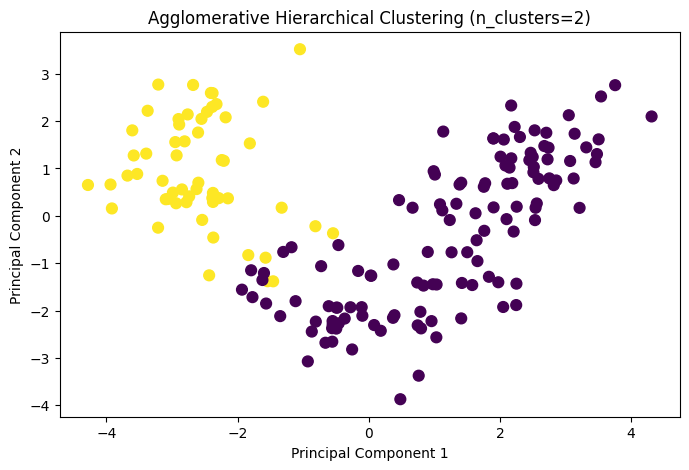

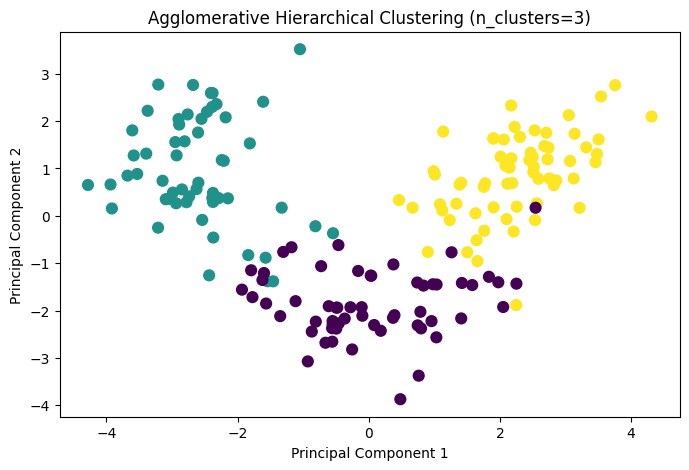

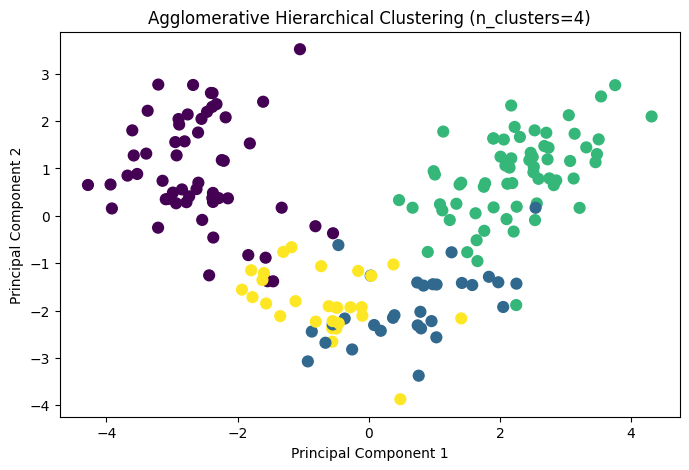

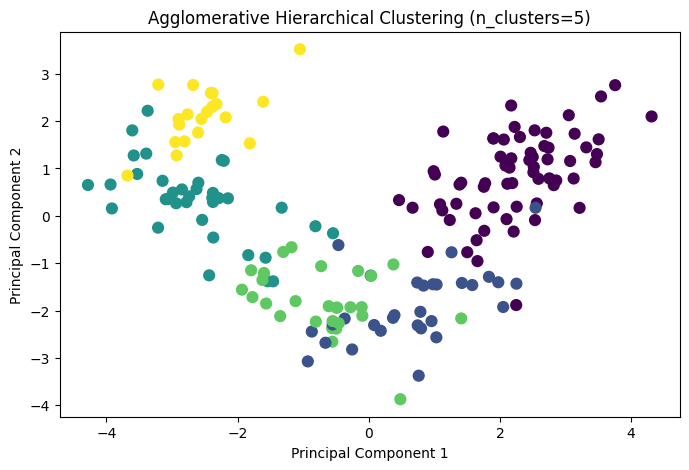

In [9]:
# Test Hierarchical Clustering with different numbers of clusters
cluster_values = [2, 3, 4, 5]

for n in cluster_values:
    hc = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    
    plt.figure(figsize=(8, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=60)
    plt.title(f'Agglomerative Hierarchical Clustering (n_clusters={n})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

#### Interpretation of Cluster Visualizations

The scatter plots above show how the Wine samples are grouped when different values of `n_clusters` are used. Since the dataset contains three actual wine classes, testing values such as 2, 3, 4, and 5 helps illustrate how under-clustering or over-clustering changes the grouping structure. Visual separation in PCA space gives a useful approximation of clustering behavior, although it does not capture all dimensions of the data.


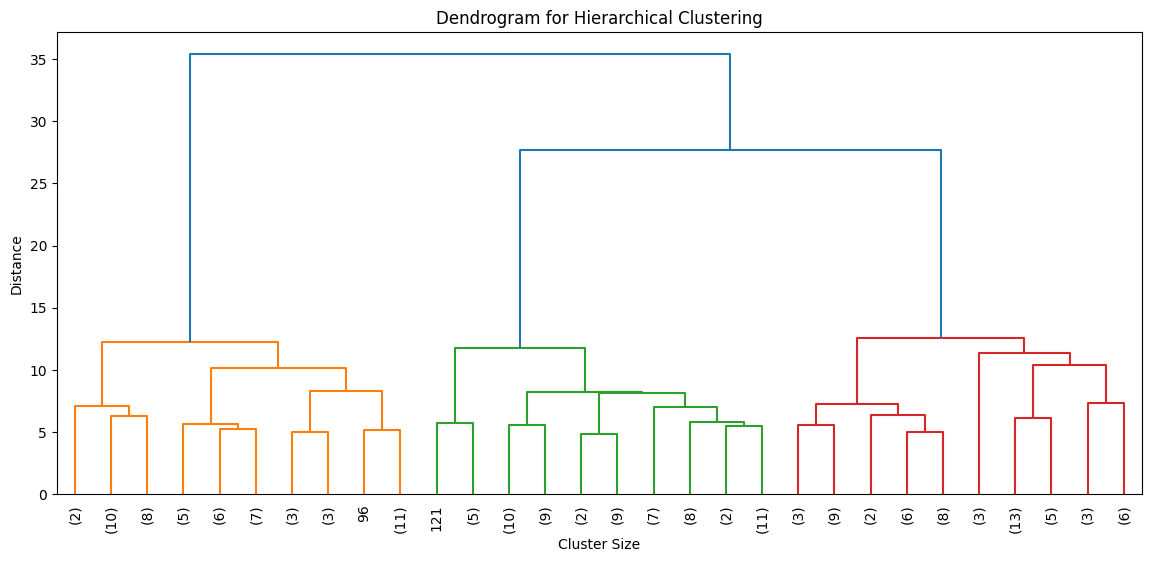

In [10]:
# Generate linkage matrix for dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

#### Dendrogram Interpretation

The dendrogram illustrates how individual observations are merged step by step into larger clusters. Large vertical jumps in linkage distance suggest meaningful separations between groups. By observing where these jumps occur, it becomes easier to estimate a reasonable number of clusters. In this dataset, the dendrogram may suggest that approximately three major groups exist, which aligns with the known class structure of the Wine dataset.


In [11]:
# Fit final Hierarchical Clustering model with 3 clusters
hc_final = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc_final.fit_predict(X_scaled)

# Add labels to DataFrame
df['HC_Cluster'] = hc_labels

# View first few rows
df[['target', 'HC_Cluster']].head()

,target,HC_Cluster
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2


#### Step 3: DBSCAN Clustering

In this step, DBSCAN is applied to the same standardized dataset. DBSCAN differs from Hierarchical Clustering because it is density-based and can identify clusters of arbitrary shape while also labeling outliers as noise points. Different values of `eps` and `min_samples` are tested to examine their influence on clustering performance.


In [12]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

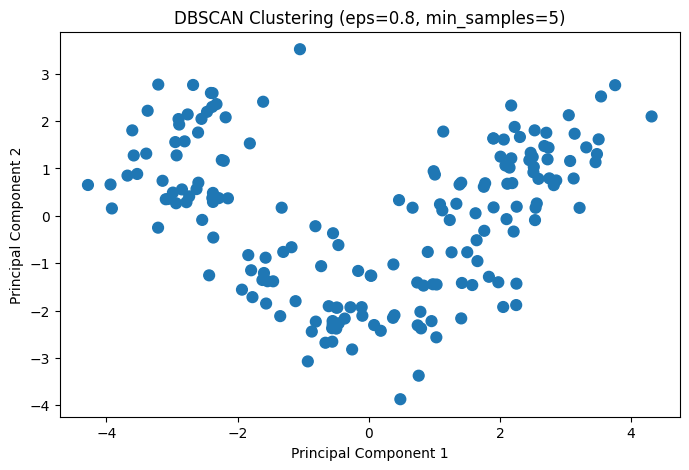

eps=0.8, min_samples=5
Number of clusters: 0
Number of noise points: 178
--------------------------------------------------


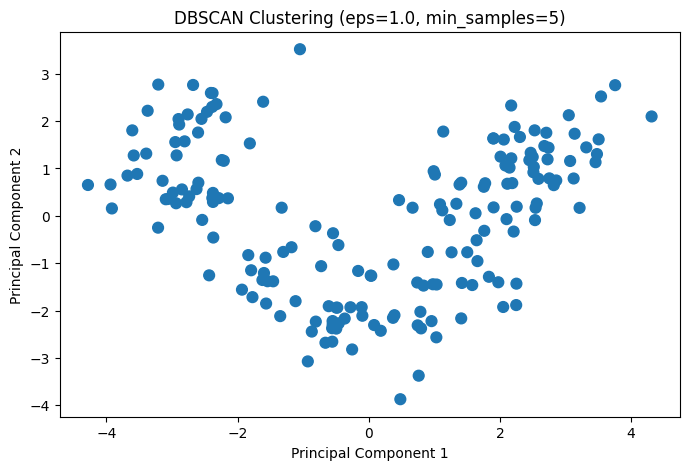

eps=1.0, min_samples=5
Number of clusters: 0
Number of noise points: 178
--------------------------------------------------


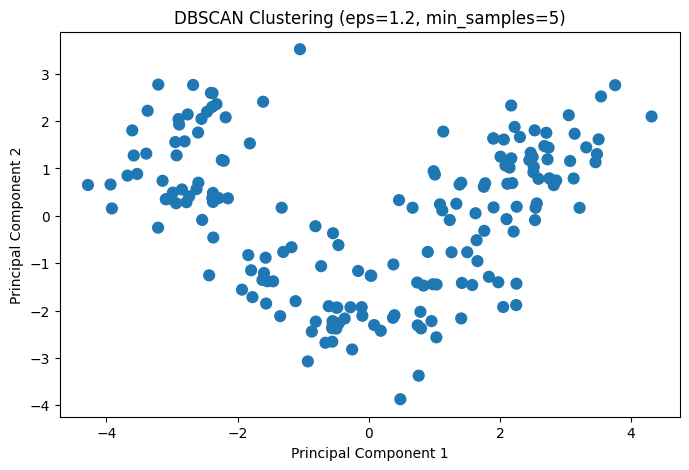

eps=1.2, min_samples=5
Number of clusters: 0
Number of noise points: 178
--------------------------------------------------


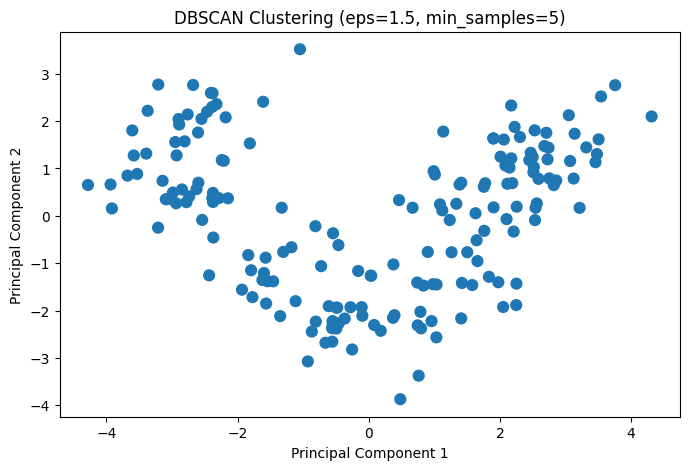

eps=1.5, min_samples=5
Number of clusters: 0
Number of noise points: 178
--------------------------------------------------


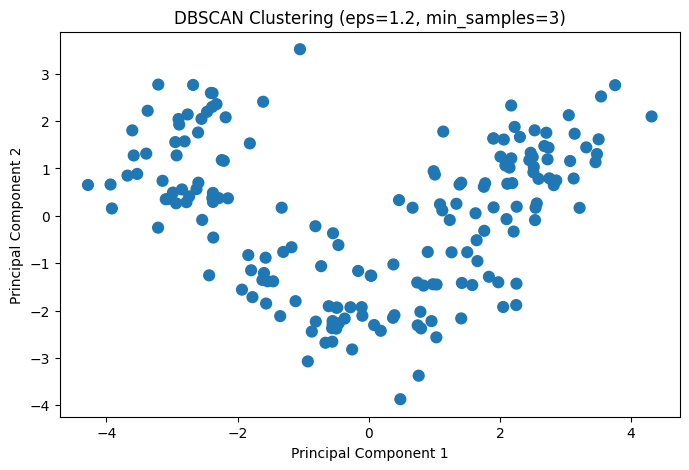

eps=1.2, min_samples=3
Number of clusters: 0
Number of noise points: 178
--------------------------------------------------


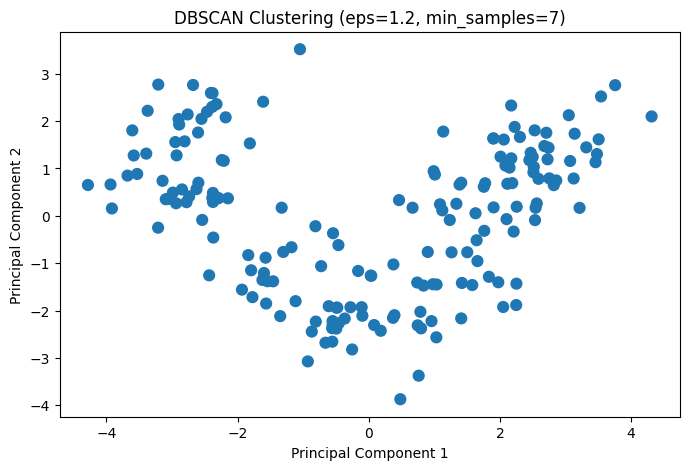

eps=1.2, min_samples=7
Number of clusters: 0
Number of noise points: 178
--------------------------------------------------


In [13]:
# Try different DBSCAN parameter combinations
dbscan_params = [
    (0.8, 5),
    (1.0, 5),
    (1.2, 5),
    (1.5, 5),
    (1.2, 3),
    (1.2, 7)
]

for eps, min_samples in dbscan_params:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    db_labels = db.fit_predict(X_scaled)
    
    unique_labels = np.unique(db_labels)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = list(db_labels).count(-1)
    
    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10', s=60)
    plt.title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()
    
    print(f"eps={eps}, min_samples={min_samples}")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise}")
    print("-" * 50)

#### Notes on DBSCAN Parameters

The `eps` parameter controls the radius within which neighboring points are searched, while `min_samples` determines the minimum number of points needed to form a dense region. Smaller `eps` values can result in more noise points, while larger `eps` values may merge distinct clusters together. Similarly, larger `min_samples` values make cluster formation stricter.

In [14]:
# Choose one DBSCAN model for final evaluation
db_final = DBSCAN(eps=1.2, min_samples=5)
db_labels = db_final.fit_predict(X_scaled)

# Add labels to DataFrame
df['DBSCAN_Cluster'] = db_labels

# Display first few rows
df[['target', 'DBSCAN_Cluster']].head()

,target,DBSCAN_Cluster
0,0,-1
1,0,-1
2,0,-1
3,0,-1
4,0,-1


In [15]:
# Count clusters and noise points
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)

print("Final DBSCAN Results")
print("Number of clusters:", n_clusters_db)
print("Number of noise points:", n_noise_db)

Final DBSCAN Results
Number of clusters: 0
Number of noise points: 178


In [16]:
# Evaluate DBSCAN clustering
# Silhouette score can only be calculated if there is more than 1 cluster
if len(set(db_labels)) > 1 and n_clusters_db > 1:
    sil_score = silhouette_score(X_scaled, db_labels)
else:
    sil_score = "Not applicable"

hom_score = homogeneity_score(y, db_labels)
comp_score = completeness_score(y, db_labels)

print("DBSCAN Evaluation Metrics")
print("Silhouette Score:", sil_score)
print("Homogeneity Score:", hom_score)
print("Completeness Score:", comp_score)

DBSCAN Evaluation Metrics
Silhouette Score: Not applicable
Homogeneity Score: 0.0
Completeness Score: 1.0


In [17]:
# Also evaluate final Hierarchical Clustering model for comparison
hc_sil_score = silhouette_score(X_scaled, hc_labels)
hc_hom_score = homogeneity_score(y, hc_labels)
hc_comp_score = completeness_score(y, hc_labels)

print("Hierarchical Clustering Evaluation Metrics")
print("Silhouette Score:", hc_sil_score)
print("Homogeneity Score:", hc_hom_score)
print("Completeness Score:", hc_comp_score)


Hierarchical Clustering Evaluation Metrics
Silhouette Score: 0.2774439826952266
Homogeneity Score: 0.790429271831654
Completeness Score: 0.7825408201875712


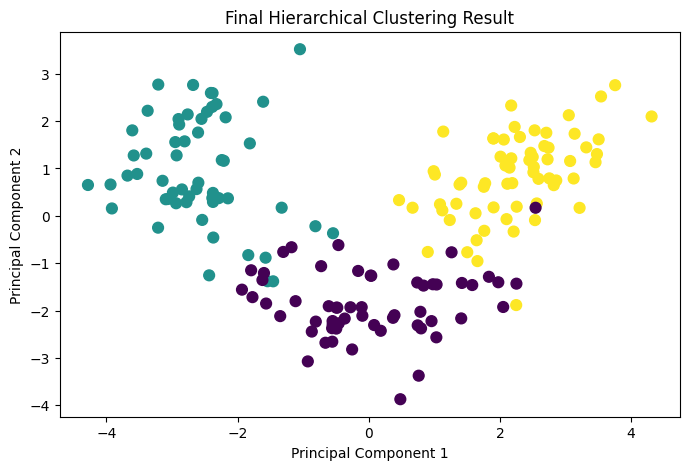

In [18]:
# Visualize final Hierarchical Clustering result
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels, cmap='viridis', s=60)
plt.title('Final Hierarchical Clustering Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


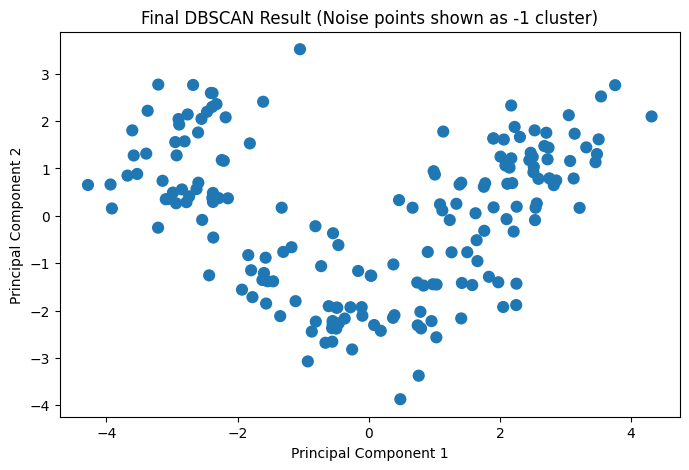

In [19]:
# Visualize final DBSCAN result with noise points
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10', s=60)
plt.title('Final DBSCAN Result (Noise points shown as -1 cluster)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


#### Step 4: Analysis and Insights

#### Comparison Between Hierarchical Clustering and DBSCAN

The results show that Hierarchical Clustering and DBSCAN approach the Wine dataset differently. Hierarchical Clustering forms clusters by progressively merging observations based on distance, while DBSCAN groups observations based on density and is capable of identifying noise points.

Hierarchical Clustering performed well on this dataset because the Wine data appears to have relatively well-separated groups. Using `n_clusters=3` produced results that aligned reasonably well with the known target classes. The dendrogram also provided a useful way to inspect the hierarchical relationships among observations and estimate a meaningful number of clusters.

DBSCAN, on the other hand, was more sensitive to parameter selection. Small changes in `eps` and `min_samples` noticeably changed the number of clusters and the number of points labeled as noise. This behavior demonstrates both a strength and a weakness of DBSCAN. It is powerful when the data contains irregular cluster shapes or outliers, but it can be difficult to tune when the density structure is not obvious.

#### Influence of Parameters

For Hierarchical Clustering, the main parameter explored was `n_clusters`. When too few clusters were chosen, distinct groups were merged together. When too many clusters were chosen, natural groups were split unnecessarily. The dendrogram helped provide visual evidence for selecting a more appropriate number of clusters.

For DBSCAN, the `eps` parameter had a strong effect on how tightly points needed to be packed to form a cluster. Lower values led to more noise points, while higher values sometimes caused clusters to merge. The `min_samples` parameter controlled how strict the density requirement was, with larger values making it harder for clusters to form.

#### Strengths and Weaknesses

**Hierarchical Clustering Strengths**
- Easy to interpret through a dendrogram
- Works well when the number of clusters can be estimated
- Effective for datasets with a clear hierarchical structure

**Hierarchical Clustering Weaknesses**
- Requires selecting the number of clusters in advance
- Can become computationally expensive for large datasets

**DBSCAN Strengths**
- Does not require the number of clusters to be specified beforehand
- Can detect outliers as noise
- Works well for arbitrarily shaped clusters

**DBSCAN Weaknesses**
- Sensitive to parameter selection
- May perform poorly when clusters have varying densities

#### Final Reflection

Overall, Hierarchical Clustering appeared to be more suitable for the Wine dataset because the data contains fairly compact and distinguishable groups. DBSCAN was useful for exploring density-based clustering behavior, but its results depended strongly on the choice of parameters. This lab demonstrated that clustering performance depends not only on the dataset itself but also on how the algorithm and its parameters are matched to the structure of the data.


#### Conclusion

This lab provided practical experience with two important clustering techniques: Agglomerative Hierarchical Clustering and DBSCAN. By applying both methods to the Wine dataset, it became clear that different clustering algorithms reveal different aspects of the data. Hierarchical Clustering offered a strong visual and structural interpretation through the dendrogram, while DBSCAN highlighted the effects of density and noise. The evaluation metrics and visualizations showed that parameter tuning plays a significant role in clustering outcomes and that the best algorithm depends on the underlying structure of the dataset.


In [20]:
print("Hierarchical Cluster Counts:")
print(pd.Series(hc_labels).value_counts().sort_index())

print("\nDBSCAN Cluster Counts:")
print(pd.Series(db_labels).value_counts().sort_index())

Hierarchical Cluster Counts:
0    58
1    56
2    64
Name: count, dtype: int64

DBSCAN Cluster Counts:
-1    178
Name: count, dtype: int64
